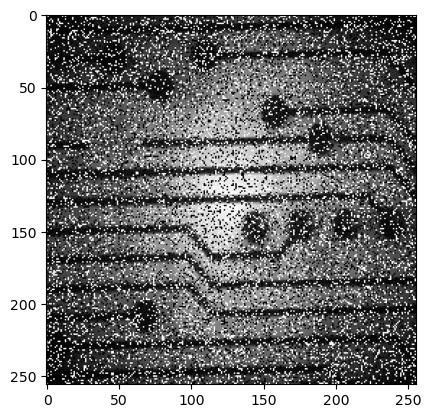

In [108]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

image = cv2.imread("images/noised_circuit.png", cv2.IMREAD_GRAYSCALE)

# Visualizar imagen
plt.imshow(image, cmap="gray",  vmin=0, vmax=255)
plt.show()

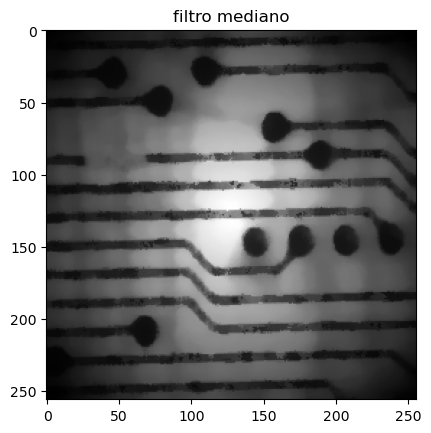

In [109]:
#Aplique un filtro mediano 3x3 a la imagen con ruido
from skimage import data
from skimage.morphology import disk, ball
from skimage.filters.rank import median
import numpy as np

rng = np.random.default_rng()

volume = rng.integers(0, 255, size=(10,10,10), dtype=np.uint8)
med = median(image, disk(5))
med_vol = median(volume, ball(5))

# Visualizar imagen
plt.imshow(med, cmap="gray")
plt.title("filtro mediano")
plt.show()


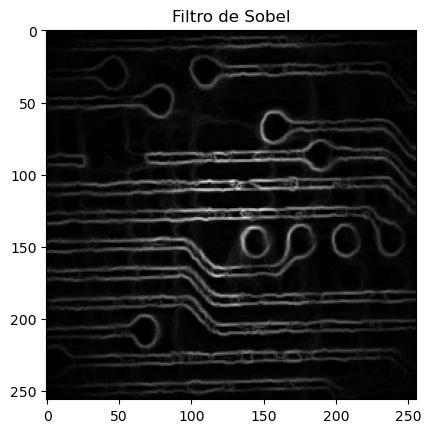

In [110]:
from skimage.filters import sobel_h, sobel_v, sobel
from skimage import exposure

#Calcula bordes usando el filtro de sobel
img_s = sobel(med)
# Visualizar imagen
plt.imshow(img_s, cmap="gray")
plt.title("Filtro de Sobel")
plt.show()


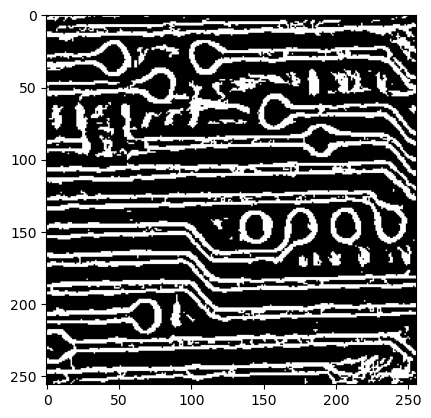

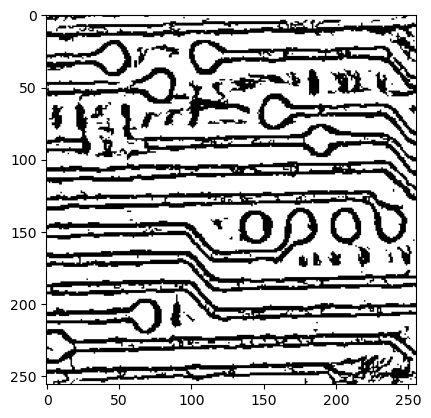

In [111]:
from skimage.filters import threshold_local
#Umbralizar
# ---------- Umbralizacion con OTSU a la imagen --------
threshold = threshold_local(img_s, block_size=17, method='mean')
binary_image = img_s > threshold
thresholded_image = (binary_image*255).astype(np.uint8)
# Visualizar imagen
plt.imshow(thresholded_image, cmap="gray", vmin=0, vmax=255)
plt.show()

#Resultado invertido
inverted_image = 255 - thresholded_image
plt.imshow(inverted_image, cmap="gray", vmin=0, vmax=255)
plt.show()

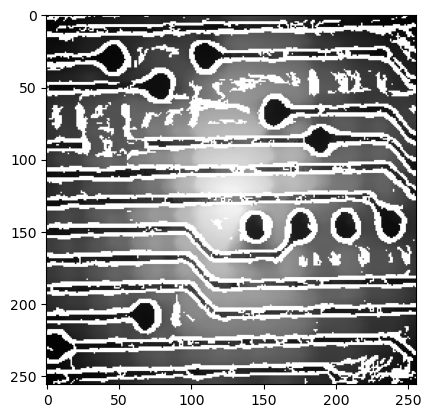

In [112]:
dst = cv2.bitwise_or(med,thresholded_image,0)

plt.imshow(dst, cmap="gray")
plt.show()

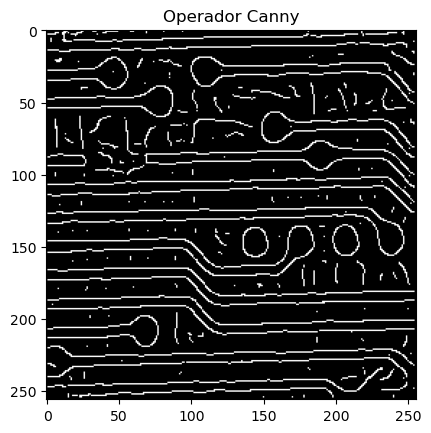

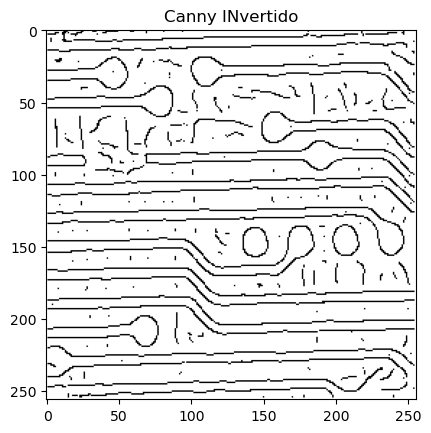

In [ ]:
# Operador Canny
from skimage.feature import canny

sigma=2 #desviacion estandar
low_threshold=0
high_threshold=1

edges2 = canny(med, sigma=sigma, low_threshold=low_threshold, high_threshold=high_threshold)

# Visualizar imagen
plt.imshow(edges2, cmap="gray")
plt.title("Operador Canny")
plt.show()

inverted_canny = 255 - edges2
plt.imshow(inverted_canny, cmap="gray")
plt.title("Canny Invertido")
plt.show()


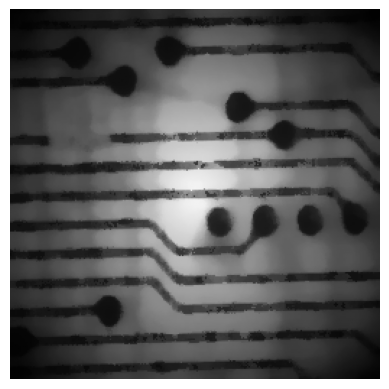

In [ ]:
outlined = med.copy()

outlined[inverted_canny] = 255
plt.imshow(outlined, cmap='gray', vmin=0, vmax=255)

plt.axis('off')
plt.show()

int64
uint8


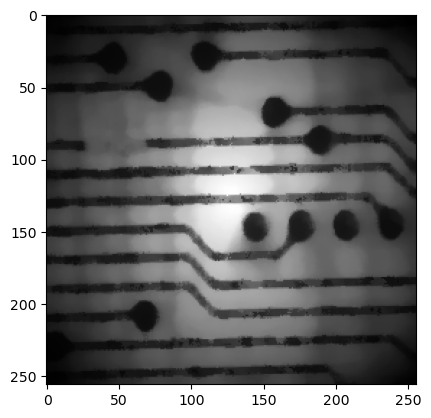

In [146]:
# Imagen final
print(inverted_canny.dtype)
print(med.dtype)
final_image = cv2.bitwise_or(edges2.astype(np.uint8), med,0)

# Visualizar imagen final
plt.imshow(final_image, cmap="gray")
plt.show()